# 未知樹種への外挿 — 特徴量設計と LOSO 検証

`epo_band_visualization.ipynb` の探索を踏まえ、**未知樹種に外挿できそうな特徴量**を
できるだけ列挙し、代表的な機械学習モデルを **LOSO (Leave-One-Species-Out) CV** で比較する。

**なぜ LOSO か**: train/test は樹種が完全に別集合。1樹種を丸ごと検証用に抜く LOSO は
「学習に無い樹種を予測する」本番設定を train 内で忠実に再現する。

**リーク防止の要点**: EPO（樹種部分空間の直交除去）は **各 fold の学習側樹種だけ** で推定し、
抜いた樹種には適用のみ。標準化も学習側で fit する。


In [1]:
import numpy as np, pandas as pd, warnings
import matplotlib.pyplot as plt, matplotlib as mpl
from scipy.ndimage import uniform_filter1d
from pathlib import Path
warnings.filterwarnings('ignore')
mpl.rcParams['font.family'] = 'Hiragino Sans'; mpl.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 110

from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

DATA = Path('data') if Path('data/train_clean.csv').exists() else Path('../data')
train = pd.read_csv(DATA / 'train.csv', encoding='shift_jis')
wn = train.columns[4:].astype(float).values; nm = 1e7 / wn
X = train[train.columns[4:]].values.astype(float)
y = train['含水率'].values; sp = train['樹種'].values
order = np.argsort(nm); nm, X = nm[order], X[:, order]
species_sorted = sorted(np.unique(sp))

def snv(M): return (M - M.mean(1, keepdims=True)) / M.std(1, keepdims=True)
X_snv = snv(X)
print('train:', train.shape, '| 樹種数', len(species_sorted), '| MC %.1f–%.1f%%' % (y.min(), y.max()))


train: (1322, 1559) | 樹種数 13 | MC 0.8–298.6%


## 1. 波長帯の再抽出（feature_exploration セクション6 と同一）

In [2]:
def corr_with_y(M, yv):
    Mc = M - M.mean(0); yc = yv - yv.mean()
    return (Mc * yc[:, None]).sum(0) / (np.sqrt((Mc**2).sum(0)) * np.sqrt((yc**2).sum()) + 1e-12)

R = np.array([corr_with_y(X_snv[sp == s], y[sp == s]) for s in species_sorted])
score = uniform_filter1d(np.abs(np.sign(R).sum(0)) / len(species_sorted) * np.abs(R).mean(0), 9)

def detect_bands(thr, min_width_nm=20):
    above = score >= thr; out = []; i = 0; n = len(nm)
    while i < n:
        if above[i]:
            j = i
            while j < n and above[j]: j += 1
            if nm[j-1] - nm[i] >= min_width_nm: out.append(slice(i, j))
            i = j
        else: i += 1
    return out

bsl = detect_bands(float(np.quantile(score, 0.80)))
lo, hi = nm[bsl[2].stop-1], nm[bsl[3].start]              # B3–B4間の水バンド(1940)領域
ids = np.where((nm >= lo) & (nm <= hi))[0]; gap = slice(ids[0], ids[-1]+1)
band_slices = [('B%d' % (k+1), s) for k, s in enumerate(bsl)] + [('水1940', gap)]
print('使用バンド:', [(n, '%d-%dnm' % (round(nm[s.start]), round(nm[s.stop-1]))) for n, s in band_slices])


使用バンド: [('B1', '1190-1225nm'), ('B2', '1375-1470nm'), ('B3', '1867-1904nm'), ('B4', '1985-2041nm'), ('B5', '2315-2405nm'), ('水1940', '1904-1985nm')]


## 2. 外挿に有望な特徴量の設計

EPO 補正後のバンドスペクトルから、物理的意味の異なる特徴量を作る。
各バンド × 各特徴量を**全特徴**として列挙し、外挿ロバスト性で順位付けする。

- **特徴量**: 平均 / 最大 / 振幅 / 傾き / CR深さ（連続体除去深さ）
- **バンド**: B1–B5 ＋ 水バンド(1940) → 6 バンド × 5 特徴量 = 30 特徴量
- **外挿ロバスト性** = 樹種間の符号一致率 × 樹種内平均|r|（高いほど樹種に依らず MC と結ぶ）


In [3]:
def epo_projection(D, k):
    _, _, Vt = np.linalg.svd(D, full_matrices=False); G = Vt[:k].T
    return np.eye(D.shape[1]) - G @ G.T
def species_clutter(Xb, spv):
    gm = Xb.mean(0); return np.array([Xb[spv == s].mean(0) - gm for s in np.unique(spv)])

def f_mean(E, w):  return E.mean(1)
def f_max(E, w):   return E.max(1)
def f_amp(E, w):   return E.max(1) - E.min(1)
def f_slope(E, w): return np.polyfit(w, E.T, 1)[0]
def f_cr(E, w):
    dw = w[-1] - w[0]; cont = E[:, :1] + (E[:, -1:] - E[:, :1]) * ((w - w[0]) / dw)[None, :]
    return (cont - E).max(1)
FEAT_FNS = {'平均': f_mean, '最大': f_max, '振幅': f_amp, '傾き': f_slope, 'CR深さ': f_cr}
N_COMP = 2

def build_features(Xtr, Xte, sptr):
    """EPOを学習側で推定→両者を変換→特徴量化（リークなし）"""
    Ftr, Fte, names = [], [], []
    for bn, sl in band_slices:
        P = epo_projection(species_clutter(Xtr[:, sl], sptr), N_COMP)
        Etr, Ete, w = Xtr[:, sl] @ P, Xte[:, sl] @ P, nm[sl]
        for fn, f in FEAT_FNS.items():
            Ftr.append(f(Etr, w)); Fte.append(f(Ete, w)); names.append('%s_%s' % (bn, fn))
    return np.column_stack(Ftr), np.column_stack(Fte), names

# 外挿ロバスト性の順位付け（全trainでEPO推定＝スクリーニング用。検証は次節LOSO）
Fall, _, names = build_features(X_snv, X_snv, sp)
rank = []
for j, fn in enumerate(names):
    rs = np.array([np.corrcoef(Fall[sp == s, j], y[sp == s])[0, 1] for s in species_sorted])
    sign = abs(np.sign(rs).sum()) / len(rs); mar = np.nanmean(np.abs(rs))
    rank.append({'feature': fn, '符号一致率': round(sign, 2), '樹種内平均|r|': round(mar, 2),
                 '全体|r|': round(abs(np.corrcoef(Fall[:, j], y)[0, 1]), 2),
                 'ロバスト性': round(sign * mar, 3)})
rank = pd.DataFrame(rank).sort_values('ロバスト性', ascending=False).reset_index(drop=True)
display(rank)
print('上位ほど未知樹種に外挿しやすいと期待。以降のモデルは全30特徴量を入力に使う。')


,feature,符号一致率,樹種内平均|r|,全体|r|,ロバスト性
0,B1_CR深さ,1.00,0.91,0.75,0.912
1,B1_最大,1.00,0.91,0.75,0.910
2,B1_平均,1.00,0.90,0.75,0.905
3,B1_振幅,1.00,0.90,0.73,0.904
4,水1940_振幅,1.00,0.89,0.71,0.887
5,水1940_平均,1.00,0.89,0.74,0.885
6,水1940_最大,1.00,0.88,0.68,0.880
7,B2_最大,1.00,0.88,0.68,0.878
8,水1940_傾き,1.00,0.88,0.74,0.878
9,B1_傾き,1.00,0.86,0.71,0.863


上位ほど未知樹種に外挿しやすいと期待。以降のモデルは全30特徴量を入力に使う。


## 3. LOSO 交差検証 — 代表モデルの比較

1樹種ずつ抜いて学習→抜いた樹種を予測。EPO・標準化は学習側で fit。

- **モデル**: PLS / Ridge（線形・NIR定番）, RandomForest / GBM（非線形）, SVR（RBF）, Baseline（学習平均）
- **指標**: pooled RMSE（全予測まとめ）, macro RMSE（樹種ごとRMSEの平均＝樹種を等重み）, R², MAE


In [4]:
models = {
    'PLS':   lambda: PLSRegression(n_components=8),
    'Ridge': lambda: RidgeCV(alphas=np.logspace(-3, 3, 13)),
    'RF':    lambda: RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1),
    'GBM':   lambda: GradientBoostingRegressor(random_state=0),
    'SVR':   lambda: SVR(C=10, gamma='scale'),
}
preds = {m: np.full(len(y), np.nan) for m in list(models) + ['Baseline']}
for s in species_sorted:                              # LOSO
    te = sp == s; tr = ~te
    Ftr, Fte, _ = build_features(X_snv[tr], X_snv[te], sp[tr])
    scaler = StandardScaler().fit(Ftr)
    Xtr, Xte = scaler.transform(Ftr), scaler.transform(Fte)
    preds['Baseline'][te] = y[tr].mean()
    for mn, factory in models.items():
        est = factory(); est.fit(Xtr, y[tr])
        preds[mn][te] = np.ravel(est.predict(Xte))

per_sp = {}
rows = []
for mn, p in preds.items():
    rmse_s = np.array([np.sqrt(mean_squared_error(y[sp == s], p[sp == s])) for s in species_sorted])
    per_sp[mn] = rmse_s
    rows.append({'model': mn, 'pooled_RMSE': round(np.sqrt(mean_squared_error(y, p)), 2),
                 'macro_RMSE': round(rmse_s.mean(), 2), 'pooled_R2': round(r2_score(y, p), 3),
                 'MAE': round(mean_absolute_error(y, p), 2)})
res = pd.DataFrame(rows).sort_values('macro_RMSE').reset_index(drop=True)
display(res)


,model,pooled_RMSE,macro_RMSE,pooled_R2,MAE
0,RF,26.22,22.65,0.720,17.16
1,GBM,27.66,24.41,0.688,18.89
2,SVR,31.10,25.42,0.606,20.87
3,Ridge,30.60,26.27,0.618,22.54
4,PLS,32.56,27.60,0.568,23.82
5,Baseline,50.30,47.09,-0.031,38.86


### 3.1 樹種ごとの誤差分布と予測 vs 実測

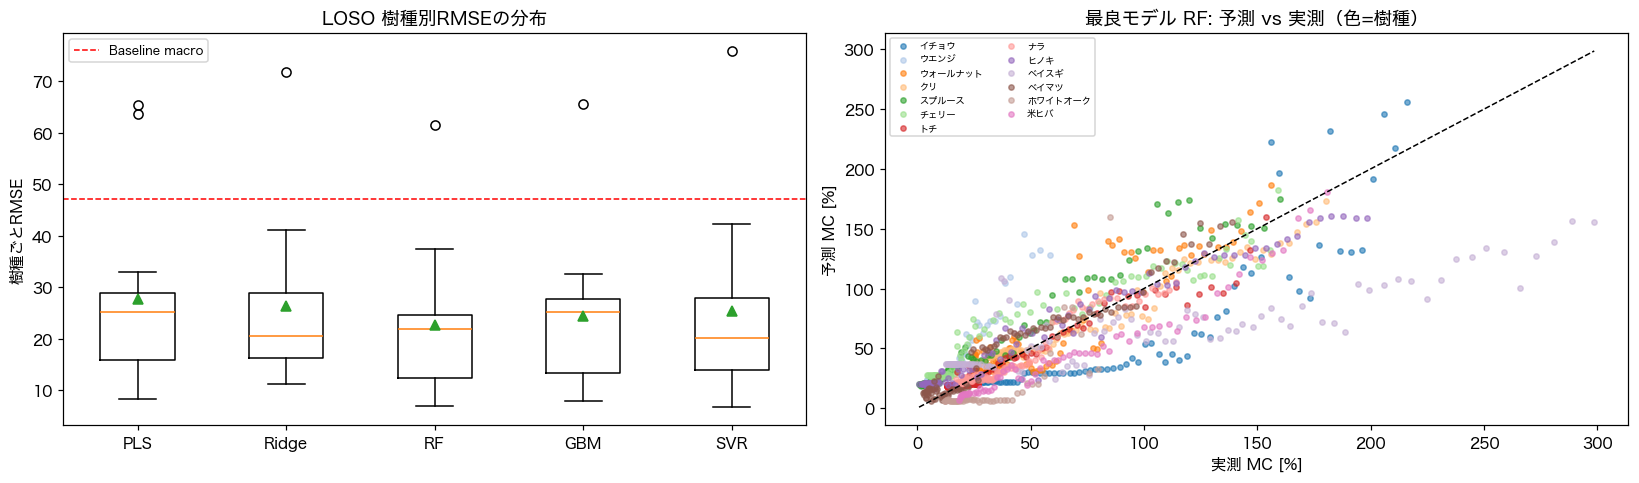

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
mnames = [m for m in preds if m != 'Baseline']
ax[0].boxplot([per_sp[m] for m in mnames], labels=mnames, showmeans=True)
ax[0].axhline(per_sp['Baseline'].mean(), color='red', ls='--', lw=1, label='Baseline macro')
ax[0].set_ylabel('樹種ごとRMSE'); ax[0].set_title('LOSO 樹種別RMSEの分布'); ax[0].legend(fontsize=8)

best = res.iloc[0]['model']
cmap = plt.get_cmap('tab20'); col = {s: cmap(i % 20) for i, s in enumerate(species_sorted)}
for s in species_sorted:
    m = sp == s; ax[1].scatter(y[m], preds[best][m], s=12, color=col[s], alpha=.6, label=s)
lim = [min(y.min(), preds[best].min()), y.max()]
ax[1].plot(lim, lim, 'k--', lw=1)
ax[1].set_xlabel('実測 MC [%]'); ax[1].set_ylabel('予測 MC [%]')
ax[1].set_title('最良モデル %s: 予測 vs 実測（色=樹種）' % best)
ax[1].legend(fontsize=6, ncol=2)
plt.tight_layout(); plt.show()


## 4. 方針A: 微分前処理の当たり付け

現状は **SNVのみ**。ここに SG微分を噛ませると外挿が改善するかを当たり付ける。
- **SNV+SG1 / SNV+SG2** を基底に、バンド抽出からLOSOまで**同一手順**を回す（前処理ごとにバンドは再抽出）。
- 微分スペクトルでは `平均`/`CR深さ` が無意味になるため、特徴量を **最大/最小/振幅/傾き** に差し替える（生・SNVは従来の5特徴）。
- SG窓幅・次数は feature_exploration の値（11/2, 15/2）に固定。比較指標は **macro_RMSE**。


In [6]:
from scipy.signal import savgol_filter

def f_min(E, w): return E.min(1)
DERIV_FNS = {'最大': f_max, '最小': f_min, '振幅': f_amp, '傾き': f_slope}  # 微分向け特徴

def bands_from_base(base, q=0.80, min_width_nm=20):
    R = np.array([corr_with_y(base[sp == s], y[sp == s]) for s in species_sorted])
    sc = uniform_filter1d(np.abs(np.sign(R).sum(0)) / len(species_sorted) * np.abs(R).mean(0), 9)
    above = sc >= np.quantile(sc, q); out = []; i = 0; n = len(nm)
    while i < n:
        if above[i]:
            j = i
            while j < n and above[j]: j += 1
            if nm[j-1] - nm[i] >= min_width_nm: out.append(slice(i, j))
            i = j
        else: i += 1
    return out

def models_for(nfeat):
    return {'PLS': lambda: PLSRegression(n_components=min(8, nfeat)),
            'Ridge': lambda: RidgeCV(alphas=np.logspace(-3, 3, 13)),
            'RF': lambda: RandomForestRegressor(n_estimators=300, random_state=0, n_jobs=-1),
            'GBM': lambda: GradientBoostingRegressor(random_state=0),
            'SVR': lambda: SVR(C=10, gamma='scale')}

def run_loso(base, feat_fns):
    """前処理済み base でバンド抽出→EPO(fold内)→特徴量→LOSO。各モデルの(pooled, macro)RMSEを返す"""
    bsl = bands_from_base(base)
    def build(tr, te):
        Ftr, Fte = [], []
        for sl in bsl:
            P = epo_projection(species_clutter(base[tr][:, sl], sp[tr]), N_COMP)
            Etr, Ete, w = base[tr][:, sl] @ P, base[te][:, sl] @ P, nm[sl]
            for f in feat_fns.values():
                Ftr.append(f(Etr, w)); Fte.append(f(Ete, w))
        return np.column_stack(Ftr), np.column_stack(Fte)
    mods = models_for(len(bsl) * len(feat_fns))
    preds = {m: np.full(len(y), np.nan) for m in mods}
    for s in species_sorted:
        te = sp == s; tr = ~te
        Ftr, Fte = build(tr, te)
        scaler = StandardScaler().fit(Ftr); a, b = scaler.transform(Ftr), scaler.transform(Fte)
        for mn, fac in mods.items():
            est = fac(); est.fit(a, y[tr]); preds[mn][te] = np.ravel(est.predict(b))
    out = {mn: (np.sqrt(mean_squared_error(y, p)),
                np.mean([np.sqrt(mean_squared_error(y[sp == s], p[sp == s])) for s in species_sorted]))
           for mn, p in preds.items()}
    return len(bsl), out

X_d1 = savgol_filter(X_snv, 11, 2, deriv=1, axis=1)
X_d2 = savgol_filter(X_snv, 15, 2, deriv=2, axis=1)
configs = {'SNV(基準)': (X_snv, FEAT_FNS), 'SNV+SG1': (X_d1, DERIV_FNS), 'SNV+SG2': (X_d2, DERIV_FNS)}

comp = []
for name, (base, ff) in configs.items():
    nb_, out = run_loso(base, ff)
    for mn, (pooled, macro) in out.items():
        comp.append({'前処理': name, 'n_bands': nb_, 'model': mn,
                     'pooled_RMSE': round(pooled, 2), 'macro_RMSE': round(macro, 2)})
comp = pd.DataFrame(comp)
pivot = comp.pivot(index='model', columns='前処理', values='macro_RMSE')
print('macro_RMSE（前処理 × モデル, 小さいほど良い）'); display(pivot)
print('前処理ごとの最良:', {n: '%s %.2f' % (comp[comp.前処理==n].loc[comp[comp.前処理==n].macro_RMSE.idxmin(), 'model'],
      comp[comp.前処理==n].macro_RMSE.min()) for n in configs})


macro_RMSE（前処理 × モデル, 小さいほど良い）


前処理,SNV(基準),SNV+SG1,SNV+SG2
model,,,
GBM,24.44,32.62,29.32
PLS,39.71,27.18,29.09
RF,22.84,30.97,28.90
Ridge,30.18,25.41,28.77
SVR,24.83,30.94,27.52


前処理ごとの最良: {'SNV(基準)': 'RF 22.84', 'SNV+SG1': 'Ridge 25.41', 'SNV+SG2': 'SVR 27.52'}


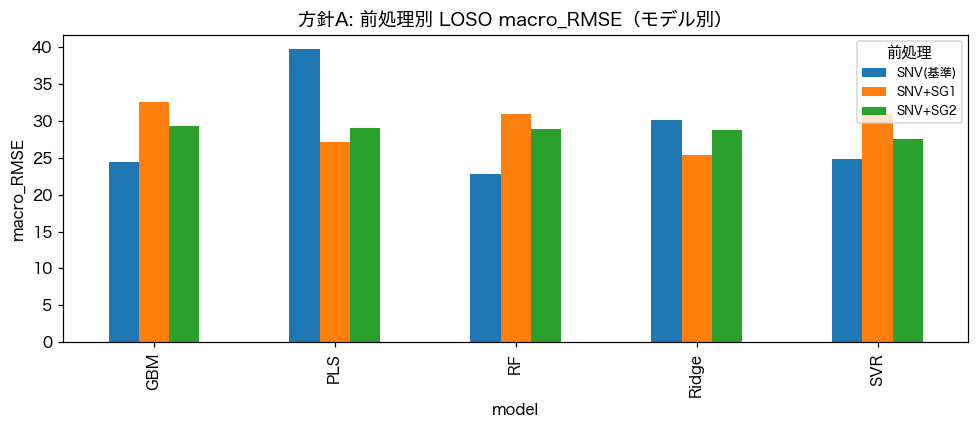

結論の読み方: SNV(基準)の最良値を微分系が下回らなければ、微分追加の効果なし。


In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
pivot.plot.bar(ax=ax)
ax.set_ylabel('macro_RMSE'); ax.set_title('方針A: 前処理別 LOSO macro_RMSE（モデル別）')
ax.legend(title='前処理', fontsize=8); plt.tight_layout(); plt.show()
print('結論の読み方: SNV(基準)の最良値を微分系が下回らなければ、微分追加の効果なし。')


## 5. まとめ

- LOSO は未知樹種設定。全モデルが Baseline（学習平均）を大きく下回る RMSE なら、
  EPO＋バンド特徴量は **樹種をまたいで MC 情報を持つ**＝外挿に寄与している。
- 非線形モデル（RF/GBM）が線形（PLS/Ridge）を上回る場合、MC は特徴量に非線形に効く。
- `macro_RMSE` は MC スケールが大きく異なる樹種を等重みで見るため、外挿の公平な指標。
- **方針A（セクション4）の所見**: SG1/SG2微分を足しても SNV のみの最良値を超えなければ、
  微分前処理は外挿に寄与しない。その場合は前処理を深追いせず、EPO成分数(N_COMP)・
  特徴量選択・モデルのハイパラ調整（LOSO内側のネストCV）に注力する。
